In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import mlacca_functions as mlcf

In [2]:
save_dir = 'data\\plots\\van_krevelens'

In [3]:
def rectangle(ax,p1,p2,**kwargs):
    h = p2[1]-p2[0]
    w = p1[1]-p1[0]
    rect=plt.Rectangle((p1[0],p2[0]),w,h,**kwargs)
    ax.add_patch(rect)

ls_dict ={
    'lipid': 'solid', 
    'peptide': 'dashdot',

    'carbohydrate': 'dashed',
    'amino_sugar': 'dotted', 
    
    'lignin': (0, (3, 1, 1, 1, 1, 1)), 
    'tannin': (0, (5, 1)),
    'phytochemical': (0, (3, 1, 1, 1))
}

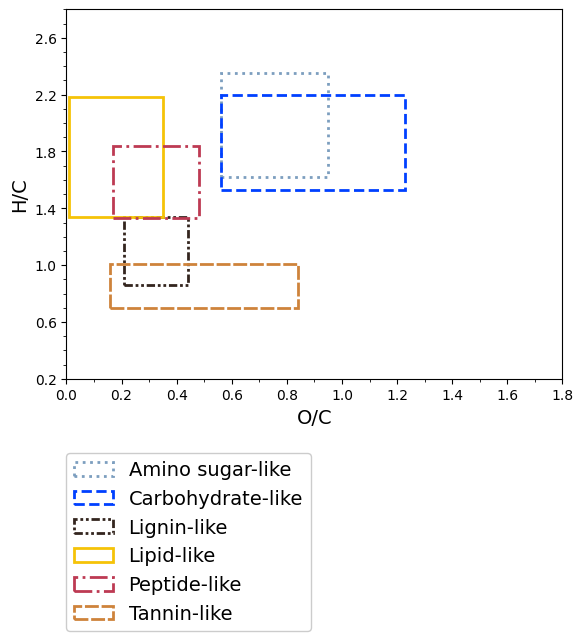

In [4]:
# DBCCR

fig, ax = plt.subplots()

for a in mlcf.laszakovits_mackay_areas:
    label = f'{a.capitalize().replace('_',' ')}-like'
    
    rectangle(ax,mlcf.laszakovits_mackay_areas[a]['O/C'],mlcf.laszakovits_mackay_areas[a]['H/C'],
              facecolor='none',edgecolor=mlcf.vk_region_colours[a],label=label,ls=ls_dict[a],lw=2)

ax.legend(framealpha=1,bbox_to_anchor=(0,-.2), loc='upper left', borderaxespad=0,fontsize=14)
ax.set_xlim(0,1.8)
ax.set_ylim(0.2,2.8)

ax.set_xticks(np.arange(np.min(ax.get_xlim()),np.max(ax.get_xlim())+1e-8,0.2))
ax.set_yticks(np.arange(np.min(ax.get_ylim()),np.max(ax.get_ylim())+1e-8,0.4))

ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))

ax.set_xlabel('O/C',fontsize=14)
ax.set_ylabel('H/C',fontsize=14)
fig.savefig(f'{save_dir}\\l&m.svg',dpi=600, facecolor = '#fff', bbox_inches='tight')

c:\Users\s2017658\.conda\envs\mlacca_env\Lib\site-packages\matplotlib\transforms.py:2036: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[0, 2] += tx
c:\Users\s2017658\.conda\envs\mlacca_env\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


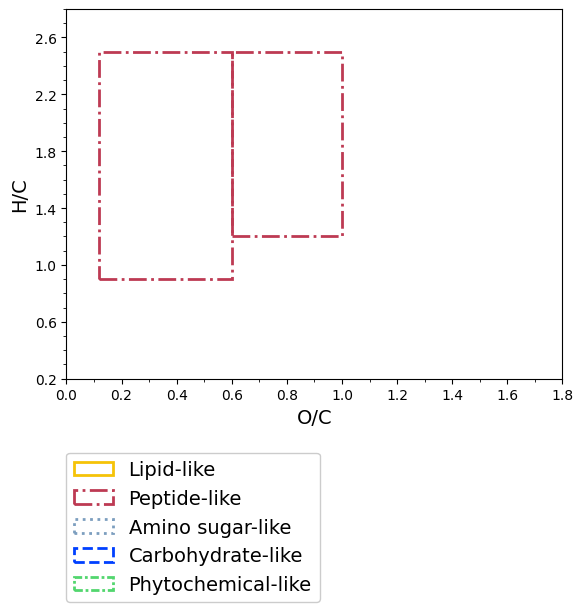

In [5]:
# MSCC

fig, ax = plt.subplots()
zorder = 0
for a in mlcf.rivasubach_areas:
    label = f'{a.capitalize().replace('_',' ').replace('1','').replace('2','')}-like' if '2' not in a else None
    
    rectangle(ax,mlcf.rivasubach_areas[a]['O/C'],mlcf.rivasubach_areas[a]['H/C'],
              facecolor='none',edgecolor=mlcf.vk_region_colours[a.replace('1','').replace('2','')],label=label,ls=ls_dict[a.replace('1','').replace('2','')],lw=2,zorder=zorder)
    
    zorder -= 1

ax.legend(framealpha=1,bbox_to_anchor=(0,-.2), loc='upper left', borderaxespad=0,fontsize=14)
ax.set_xlim(0,1.8)
ax.set_ylim(0.2,2.8)

ax.set_xticks(np.arange(np.min(ax.get_xlim()),np.max(ax.get_xlim())+1e-8,0.2))
ax.set_yticks(np.arange(np.min(ax.get_ylim()),np.max(ax.get_ylim())+1e-8,0.4))

ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))

ax.set_xlabel('O/C',fontsize=14)
ax.set_ylabel('H/C',fontsize=14)
fig.savefig(f'{save_dir}\\r-u.svg',dpi=600, facecolor = '#fff', bbox_inches='tight')

In [6]:
xlim = (0,1.8)
ylim = (.2,2.8)
zlim = (0,.8)

In [7]:
def draw_cuboid(lims:dict,ax:plt.Axes,**kwargs):

    AB = [[min(lims['O/C']),max(lims['O/C'])],
          [min(lims['H/C']),min(lims['H/C'])],
          [min(lims['N/C']),min(lims['N/C'])]]

    CD = [[min(lims['O/C']),max(lims['O/C'])],
          [max(lims['H/C']),max(lims['H/C'])],
          [min(lims['N/C']),min(lims['N/C'])]]

    ax.fill_between(*AB,*CD, **kwargs)

    EF = [[min(lims['O/C']),max(lims['O/C'])],
          [min(lims['H/C']),min(lims['H/C'])],
          [max(lims['N/C']),max(lims['N/C'])]]

    GH = [[min(lims['O/C']),max(lims['O/C'])],
          [max(lims['H/C']),max(lims['H/C'])],
          [max(lims['N/C']),max(lims['N/C'])]]
    
    ax.fill_between(*EF,*GH, **kwargs)

    ax.fill_between(*AB,*EF, **kwargs)
    ax.fill_between(*CD,*GH, **kwargs)

    BC = [[max(lims['O/C']),max(lims['O/C'])],
          [min(lims['H/C']),max(lims['H/C'])],
          [min(lims['N/C']),min(lims['N/C'])]]

    AD = [[min(lims['O/C']),min(lims['O/C'])],
          [min(lims['H/C']),max(lims['H/C'])],
          [min(lims['N/C']),min(lims['N/C'])]]
    
    FG = [[max(lims['O/C']),max(lims['O/C'])],
          [min(lims['H/C']),max(lims['H/C'])],
          [max(lims['N/C']),max(lims['N/C'])]]

    EH = [[min(lims['O/C']),min(lims['O/C'])],
          [min(lims['H/C']),max(lims['H/C'])],
          [max(lims['N/C']),max(lims['N/C'])]]

    ax.fill_between(*BC,*FG, **kwargs)
    ax.fill_between(*AD,*EH, **kwargs)

def like_label(label:str):
    return f'{label.capitalize().replace('_',' ')}-like' if label != 'pah' else 'PAH-like'

def standard_3d_plot_features(ax,label_fontsize=14):
    ax.set_xlabel('O/C',fontsize=label_fontsize,labelpad=15)
    ax.set_ylabel('H/C',fontsize=label_fontsize,labelpad=15)
    ax.set_zlabel('N/C',fontsize=label_fontsize,labelpad=8)

    mlcf.set_axis_ticks(xlim,ax,axis='x',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(xlim),upper_lim=max(xlim))
    mlcf.set_axis_ticks(ylim,ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(ylim),upper_lim=max(ylim))
    mlcf.set_axis_ticks(zlim,ax,axis='z',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(zlim),upper_lim=max(zlim))

    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)

    ax.set_box_aspect(None, zoom=0.85)

def subplots_3d_molecclass(plot_list,ypred,legend_ax,label_fontsize=14):

    for plot in plot_list:

        idx = np.where([x in plot[2] for x in ypred])[0]
        plot[0].scatter(plot[1]['O/C'].to_numpy()[idx],
                        plot[1]['H/C'].to_numpy()[idx],
                        plot[1]['N/C'].to_numpy()[idx],
                        c=[mlcf.vk_region_colours[x] for x in ypred[idx]],alpha=1,edgecolor='k',lw=.1)
        
        standard_3d_plot_features(plot[0],label_fontsize=label_fontsize)

        plot[0].view_init(**plot[3])
        plot[0].set_title(**plot[4],fontsize=24)

        if plot[0] == legend_ax:
            for cat in np.unique(ypred):
                if cat != 'unassigned':
                  plot[0].scatter(10,10,10,c=mlcf.vk_region_colours[cat],alpha=1,edgecolor='k',lw=.1,label=like_label(cat),s=100)
            plot[0].legend(framealpha=1,bbox_to_anchor=(1,1.05), loc='upper left', borderaxespad=0, fontsize=18)


In [8]:
density = 50
xx, yy, zz = np.meshgrid(np.linspace(min(xlim),max(xlim), density),
                         np.linspace(min(ylim),max(ylim), density),
                         np.linspace(min(zlim),max(zlim), density),)

xx = xx.flatten()
yy = yy.flatten()
zz = zz.flatten()
grid = np.vstack((xx,yy,zz)).T
grid_df = pd.DataFrame(grid,columns=['O/C','H/C','N/C'])

ypred_ru = mlcf.molecclass(grid_df,mlcf.rivasubach_areas)

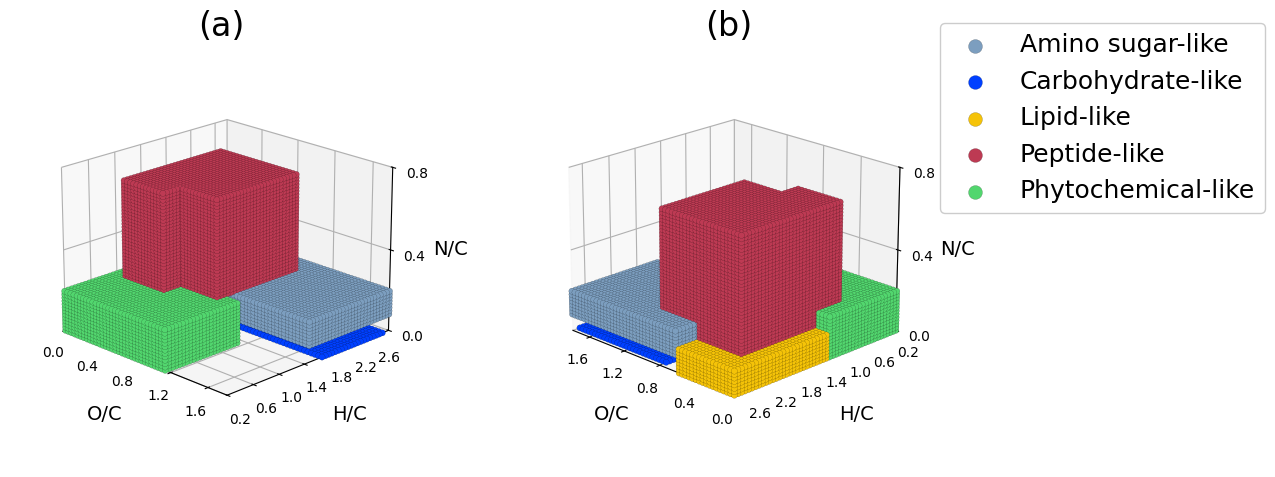

In [9]:
fig = plt.figure(figsize=(12,6)) # width, height

ax1 = fig.add_subplot(121, projection='3d',)
ax2 = fig.add_subplot(122, projection='3d',)

plot_list = [
    [ax1, grid_df, np.unique([x.replace('1','').replace('2','') for x in mlcf.rivasubach_areas.keys() if x != 'unassigned']), dict(elev=20, azim=-45), dict(label='(a)')],
    [ax2, grid_df, np.unique([x.replace('1','').replace('2','') for x in mlcf.rivasubach_areas.keys() if x != 'unassigned']), dict(elev=20, azim=135), dict(label='(b)')],
]

subplots_3d_molecclass(plot_list,ypred_ru,ax2)

fig.savefig(f'{save_dir}\\ru3d.png',dpi=400, facecolor = '#fff', bbox_inches='tight')

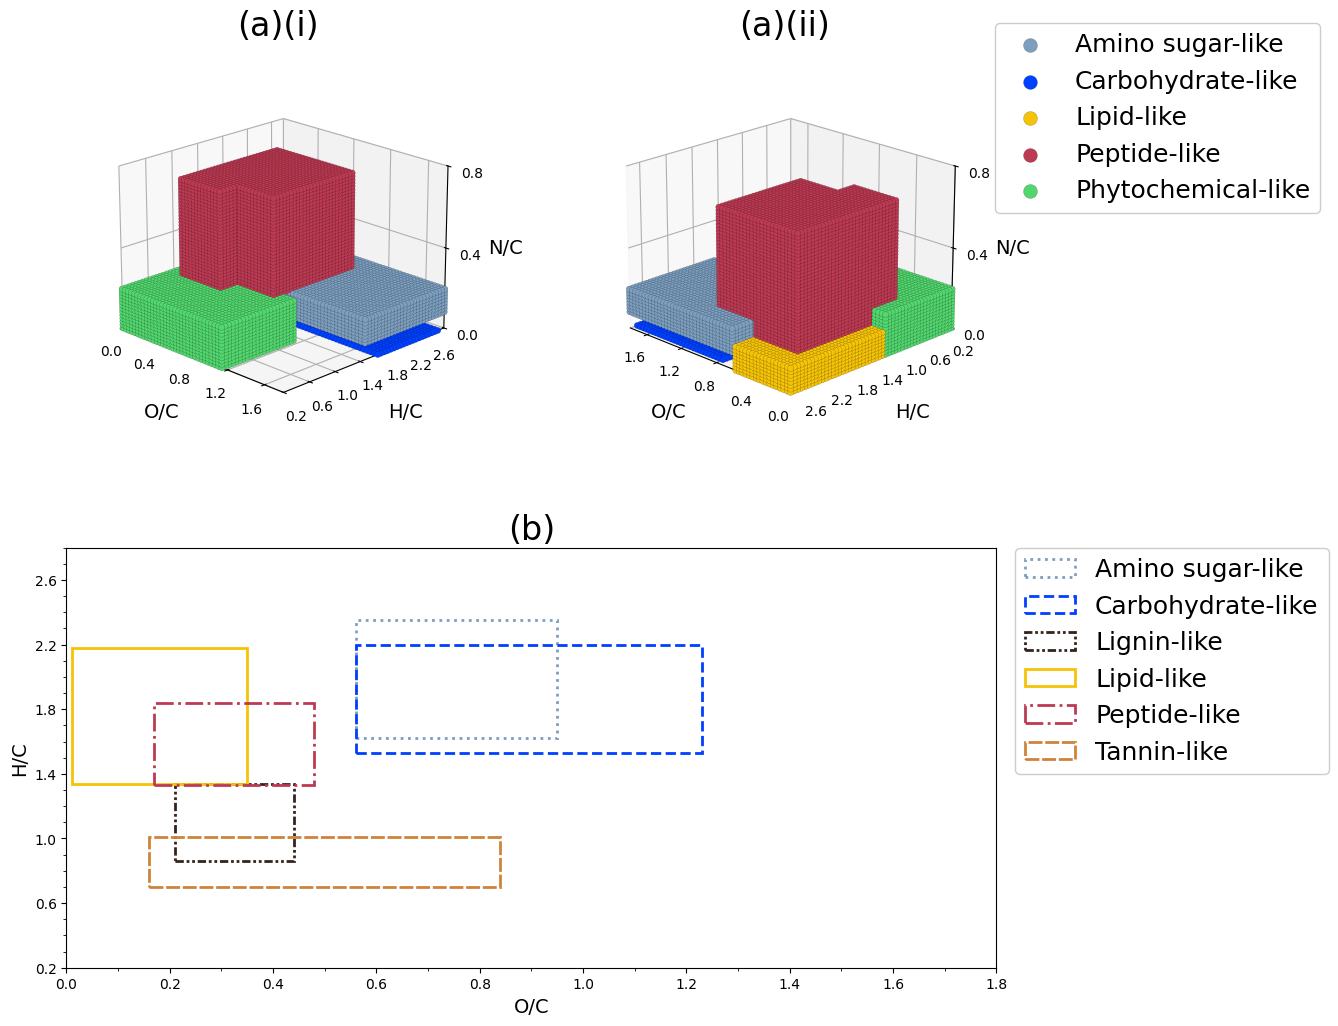

In [10]:
# both DBCCR and MSCC

fig = plt.figure(figsize=(12,12)) # width, height

ax1_1 = fig.add_subplot(221, projection='3d',)
ax1_2 = fig.add_subplot(222, projection='3d',)

plot_list = [
    [ax1_1, grid_df, np.unique([x.replace('1','').replace('2','') for x in mlcf.rivasubach_areas.keys() if x != 'unassigned']), dict(elev=20, azim=-45), dict(label='(a)(i)')],
    [ax1_2, grid_df, np.unique([x.replace('1','').replace('2','') for x in mlcf.rivasubach_areas.keys() if x != 'unassigned']), dict(elev=20, azim=135), dict(label='(a)(ii)')],
]

subplots_3d_molecclass(plot_list,ypred_ru,ax1_2)


ax2 = fig.add_subplot(212)

for a in mlcf.laszakovits_mackay_areas:
    label = f'{a.capitalize().replace('_',' ')}-like'
    
    rectangle(ax2,mlcf.laszakovits_mackay_areas[a]['O/C'],mlcf.laszakovits_mackay_areas[a]['H/C'],
              facecolor='none',edgecolor=mlcf.vk_region_colours[a],label=label,ls=ls_dict[a],lw=2)

ax2.legend(framealpha=1,bbox_to_anchor=(1.02,1), loc='upper left', borderaxespad=0,fontsize=18)
ax2.set_title('(b)',fontsize=24)
ax2.set_xlim(0,1.8)
ax2.set_ylim(0.2,2.8)

ax2.set_xticks(np.arange(np.min(ax2.get_xlim()),np.max(ax2.get_xlim())+1e-8,0.2))
ax2.set_yticks(np.arange(np.min(ax2.get_ylim()),np.max(ax2.get_ylim())+1e-8,0.4))

ax2.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))
ax2.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))

ax2.set_xlabel('O/C',fontsize=14)
ax2.set_ylabel('H/C',fontsize=14)


fig.savefig(f'{save_dir}\\l&m_&_ru3d.png',dpi=400, facecolor = '#fff', bbox_inches='tight')

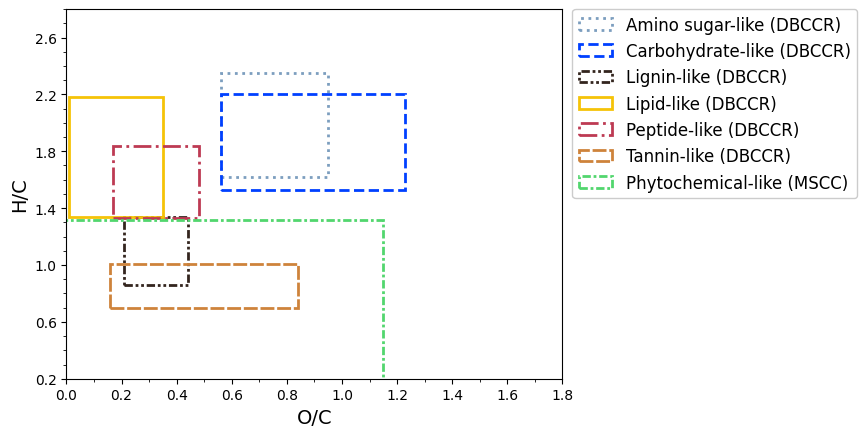

In [11]:
# show overlap of phytochemical and lignin/tannin definitions used

fig, ax = plt.subplots()

areas_compare = {x:mlcf.laszakovits_mackay_areas[x] for x in mlcf.laszakovits_mackay_areas}
areas_compare['phytochemical'] = {x:[y if y>=0 else -50 for y in mlcf.rivasubach_areas['phytochemical'][x]] for x in mlcf.rivasubach_areas['phytochemical'] if x != 'N/C'}

for a in areas_compare:
    label = f'{a.capitalize().replace('_',' ')}-like'
    
    label += ' (DBCCR)' if a in mlcf.laszakovits_mackay_areas else ' (MSCC)'

    rectangle(ax,areas_compare[a]['O/C'],areas_compare[a]['H/C'],
              facecolor='none',edgecolor=mlcf.vk_region_colours[a],label=label,ls=ls_dict[a],lw=2)

ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
ax.set_xlim(0,1.8)
ax.set_ylim(0.2,2.8)

ax.set_xticks(np.arange(np.min(ax.get_xlim()),np.max(ax.get_xlim())+1e-8,0.2))
ax.set_yticks(np.arange(np.min(ax.get_ylim()),np.max(ax.get_ylim())+1e-8,0.4))

ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))

ax.set_xlabel('O/C',fontsize=14)
ax.set_ylabel('H/C',fontsize=14)
fig.savefig(f'{save_dir}\\l&m_and_phytochemical.svg',dpi=600, facecolor = '#fff', bbox_inches='tight')